In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp "/content/drive/My Drive/MASATI.zip" "/content/MASATI.zip"

import zipfile
zip_path = "/content/MASATI.zip"
extract_path = "/content/MASATI_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Complete!")

Extraction Complete!


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.8/974.8 kB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 106.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 66.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [ ]:
from ultralytics import YOLO

# Load pre-trained YOLOv10 model
model = YOLO("yolov10m.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 32.1M/32.1M [00:00<00:00, 40.0MB/s]


In [ ]:
import os

dataset_path = "/content/MASATI_dataset"
print(os.listdir(dataset_path))

['output', 'images', 'labels']


In [ ]:
yaml_content = """path: /content/MASATI_dataset
train: images/train
val: images/val
test: images/test
nc: 1
names: ["boat"]
"""

with open("/content/MASATI_dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created successfully!")

data.yaml created successfully!


In [ ]:
import os
print(os.listdir("/content/MASATI_dataset"))

['data.yaml', 'output', 'images', 'labels']


In [ ]:
import os
import random
import shutil

# Paths
dataset_path = "/content/MASATI_dataset/images"
train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "val")
test_path = os.path.join(dataset_path, "test")

# Create folders
os.makedirs(train_path, exist_ok=True)
os.makedirs(val_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)

# Get all image files
all_images = [f for f in os.listdir(dataset_path) if f.endswith(".png")]
random.shuffle(all_images)

# Split: 70% train, 20% val, 10% test
total = len(all_images)
train_split = int(total * 0.7)
val_split = int(total * 0.2)
test_split = total - train_split - val_split

train_images = all_images[:train_split]
val_images = all_images[train_split:train_split + val_split]
test_images = all_images[train_split + val_split:]

# Move files
for img in train_images:
    shutil.move(os.path.join(dataset_path, img), os.path.join(train_path, img))

for img in val_images:
    shutil.move(os.path.join(dataset_path, img), os.path.join(val_path, img))

for img in test_images:
    shutil.move(os.path.join(dataset_path, img), os.path.join(test_path, img))

print(f"Split complete: Train={len(train_images)}, Val={len(val_images)}, Test={len(test_images)}")

Split complete: Train=3165, Val=904, Test=453


In [ ]:
import os

# Define the paths
dataset_path = "/content/MASATI_dataset/images"
train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "val")

# Create train and val folders
os.makedirs(train_path, exist_ok=True)
os.makedirs(val_path, exist_ok=True)

In [ ]:
!cat /content/MASATI_dataset/data.yaml

path: /content/MASATI_dataset
train: images/train
val: images/val
test: images/test
nc: 1
names: ["boat"]


In [ ]:
from ultralytics import YOLO

# Load YOLOv10 model
model = YOLO("yolov10m.pt")

# Train
model.train(
    data="/content/MASATI_dataset/data.yaml",
    epochs=150,
    batch=16,
    device="cuda",
    imgsz=512,
    augment=True,   # Enable augmentation
    degrees=10,     # Rotation
    translate=0.1,  # Translation
    scale=0.5,      # Scaling
    flipud=0.2,     # Vertical flip
    fliplr=0.5      # Horizontal flip
)

Ultralytics 8.3.107 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov10m.pt, data=/content/MASATI_dataset/data.yaml, epochs=150, time=None, patience=100, batch=16, imgsz=512, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, lin

100%|██████████| 755k/755k [00:00<00:00, 39.4MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1     78720  ultralytics.nn.modules.block.SCDown          [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1    228672  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 262MB/s]


AMP: checks passed ✅


...

     30/150      8.87G      3.976      2.792      2.057         29        512: 100%|██████████| 198/198 [01:21<00:00,  2.42it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 29/29 [00:09<00:00,  2.91it/s]

                   all        904        792      0.628      0.619      0.612      0.239



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


     31/150      8.95G      3.838      2.936      2.035         30        512:  13%|█▎        | 25/198 [00:10<01:09,  2.48it/s]


KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO

# Load YOLOv10 Small model
model = YOLO("/content/runs/detect/train/weights/last.pt")

# Train
model.train(
    data="/content/MASATI_dataset/data.yaml",
    epochs=150,
    batch=16,
    device="cuda",
    imgsz=512,
    augment=True,   # Enable augmentation
    degrees=10,     # Rotation
    translate=0.1,  # Translation
    scale=0.5,      # Scaling
    flipud=0.2,     # Vertical flip
    fliplr=0.5,
    resume=True    # Horizontal flip
)

Ultralytics 8.3.107 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=/content/runs/detect/train/weights/last.pt, data=/content/MASATI_dataset/data.yaml, epochs=150, time=None, patience=100, batch=16, imgsz=512, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=/content/runs/detect/train/weights/last.pt, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, sav

train: Scanning /content/MASATI_dataset/labels/train.cache... 3165 images, 1480 backgrounds, 0 corrupt: 100%|██████████| 3165/3165 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning /content/MASATI_dataset/labels/val.cache... 904 images, 458 backgrounds, 0 corrupt: 100%|██████████| 904/904 [00:00<?, ?it/s]


Plotting labels to runs/detect/train/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 129 weight(decay=0.0), 142 weight(decay=0.0005), 141 bias(decay=0.0)
Resuming training /content/runs/detect/train/weights/last.pt from epoch 31 to 150 total epochs
TensorBoard: model graph visualization added ✅
Image sizes 512 train, 512 val
Using 2 dataloader workers
Logging results to runs/detect/train
Starting training for 150 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


     60/150      12.6G      3.717      2.358      1.987         29        512: 100%|██████████| 198/198 [01:22<00:00,  2.40it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 29/29 [00:11<00:00,  2.59it/s]


                   all        904        792      0.581      0.616      0.576      0.228

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


     61/150      12.6G      3.723      2.389      1.995         11        512:  27%|██▋       | 53/198 [00:22<01:01,  2.36it/s]


KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO

# Load YOLOv10 Small model
model = YOLO("/content/drive/MyDrive/Yolo_Training/weights/last.pt")

# Train
model.train(
    data="/content/MASATI_dataset/data.yaml",
    epochs=150,
    batch=16,
    device="cuda",
    imgsz=512,
    augment=True,   # Enable augmentation
    degrees=10,     # Rotation
    translate=0.1,  # Translation
    scale=0.5,      # Scaling
    flipud=0.2,     # Vertical flip
    fliplr=0.5,
    resume=True    # Horizontal flip
)

Ultralytics 8.3.107 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/Yolo_Training/weights/last.pt, data=/content/MASATI_dataset/data.yaml, epochs=150, time=None, patience=100, batch=16, imgsz=512, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=/content/drive/MyDrive/Yolo_Training/weights/last.pt, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, 

train: Scanning /content/MASATI_dataset/labels/train.cache... 3165 images, 1514 backgrounds, 0 corrupt: 100%|██████████| 3165/3165 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning /content/MASATI_dataset/labels/val.cache... 904 images, 434 backgrounds, 0 corrupt: 100%|██████████| 904/904 [00:00<?, ?it/s]


Plotting labels to runs/detect/train/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 129 weight(decay=0.0), 142 weight(decay=0.0005), 141 bias(decay=0.0)
Resuming training /content/drive/MyDrive/Yolo_Training/weights/last.pt from epoch 61 to 150 total epochs
TensorBoard: model graph visualization added ✅
Image sizes 512 train, 512 val
Using 2 dataloader workers
Logging results to runs/detect/train
Starting training for 150 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


     90/150        13G      3.579      2.092      1.925         11        512: 100%|██████████| 198/198 [01:23<00:00,  2.36it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 29/29 [00:11<00:00,  2.53it/s]


                   all        904        810       0.71      0.685      0.702      0.297

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


     91/150        13G      3.669      2.171      1.979         19        512:  40%|████      | 80/198 [00:34<00:50,  2.34it/s]Process Process-6:
Exception ignored in: <generator object tqdm.__iter__ at 0x7bd4d1bcb6e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/tqdm/std.py", line 1196, in __iter__
    self.close()
  File "/usr/local/lib/python3.11/dist-packages/tqdm/std.py", line 1302, in close
    self.display(pos=0)
  File "/usr/local/lib/python3.11/dist-packages/tqdm/std.py", line 1495, in display
    self.sp(self.__str__() if msg is None else msg)
  File "/usr/local/lib/python3.11/dist-packages/tqdm/std.py", line 459, in print_status
    fp_write('\r' + s + (' ' * max(last_len[0] - len_s, 0)))
  File "/usr/local/lib/python3.11/dist-packages/tqdm/std.py", line 453, in fp_write
    fp_flush()
  File "/usr/local/lib/python3.11/dist-packages/tqdm/utils.py", line 196, in inner
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  Fil

KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO

# Load YOLOv10 Small model
model = YOLO("/content/drive/MyDrive/Yolo_Training/weights/last.pt")

# Train
model.train(
    data="/content/MASATI_dataset/data.yaml",
    epochs=150,
    batch=16,
    device="cuda",
    imgsz=512,
    augment=True,   # Enable augmentation
    degrees=10,     # Rotation
    translate=0.1,  # Translation
    scale=0.5,      # Scaling
    flipud=0.2,     # Vertical flip
    fliplr=0.5,
    resume=True    # Horizontal flip
)

Ultralytics 8.3.108 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/Yolo_Training/weights/last.pt, data=/content/MASATI_dataset/data.yaml, epochs=150, time=None, patience=100, batch=16, imgsz=512, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=/content/drive/MyDrive/Yolo_Training/weights/last.pt, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, 

100%|██████████| 755k/755k [00:00<00:00, 20.0MB/s]


TensorBoard: Start with 'tensorboard --logdir runs/detect/train', view at http://localhost:6006/

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1     78720  ultralytics.nn.modules.block.SCDown          [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]  

100%|██████████| 5.35M/5.35M [00:00<00:00, 95.1MB/s]


AMP: checks passed ✅


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


    120/150      8.59G      3.522      1.964      1.909         12        512: 100%|██████████| 198/198 [01:22<00:00,  2.40it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 29/29 [00:11<00:00,  2.54it/s]


                   all        904        776      0.763      0.706      0.745      0.306

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


    121/150      8.66G      3.458      2.166      1.921         18        512:  21%|██        | 42/198 [00:17<01:04,  2.40it/s]


KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO

# Load YOLOv10 Small model
model = YOLO("/content/drive/MyDrive/Yolo_Training/weights/last.pt")

# Train
model.train(
    data="/content/MASATI_dataset/data.yaml",
    epochs=150,
    batch=16,
    device="cuda",
    imgsz=512,
    augment=True,   # Enable augmentation
    degrees=10,     # Rotation
    translate=0.1,  # Translation
    scale=0.5,      # Scaling
    flipud=0.2,     # Vertical flip
    fliplr=0.5,
    resume=True    # Horizontal flip
)

Ultralytics 8.3.108 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/Yolo_Training/weights/last.pt, data=/content/MASATI_dataset/data.yaml, epochs=150, time=None, patience=100, batch=16, imgsz=512, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=/content/drive/MyDrive/Yolo_Training/weights/last.pt, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, 

train: Scanning /content/MASATI_dataset/labels/train.cache... 3165 images, 1497 backgrounds, 0 corrupt: 100%|██████████| 3165/3165 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/MASATI_dataset/labels/val.cache... 904 images, 437 backgrounds, 0 corrupt: 100%|██████████| 904/904 [00:00<?, ?it/s]


WARNING ⚠️ 'crop_fraction' is deprecated and will be removed in in the future.
Plotting labels to runs/detect/train/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 129 weight(decay=0.0), 142 weight(decay=0.0005), 141 bias(decay=0.0)
Resuming training /content/drive/MyDrive/Yolo_Training/weights/last.pt from epoch 121 to 150 total epochs
TensorBoard: model graph visualization added ✅
Image sizes 512 train, 512 val
Using 2 dataloader workers
Logging results to runs/detect/train
Starting training for 150 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all        904        776       0.79      0.702      0.752      0.318

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


    134/150      12.8G      3.494      1.867      1.907         14        512: 100%|██████████| 198/198 [01:23<00:00,  2.36it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 29/29 [00:11<00:00,  2.55it/s]


                   all        904        776       0.76      0.716      0.754      0.315

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


    135/150      12.8G      3.426      1.938      1.901          8        512:  10%|█         | 20/198 [00:09<01:23,  2.13it/s]


KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO

# Load YOLOv10 Small model
model = YOLO("/content/drive/MyDrive/Yolo_Training/weights/last.pt")

# Train
model.train(
    data="/content/MASATI_dataset/data.yaml",
    epochs=150,
    batch=16,
    device="cuda",
    imgsz=512,
    augment=True,   # Enable augmentation
    degrees=10,     # Rotation
    translate=0.1,  # Translation
    scale=0.5,      # Scaling
    flipud=0.2,     # Vertical flip
    fliplr=0.5,
    resume=True    # Horizontal flip
)

Ultralytics 8.3.108 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/Yolo_Training/weights/last.pt, data=/content/MASATI_dataset/data.yaml, epochs=150, time=None, patience=100, batch=16, imgsz=512, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=/content/drive/MyDrive/Yolo_Training/weights/last.pt, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, 

100%|██████████| 755k/755k [00:00<00:00, 113MB/s]


TensorBoard: Start with 'tensorboard --logdir runs/detect/train', view at http://localhost:6006/

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1     78720  ultralytics.nn.modules.block.SCDown          [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]  

100%|██████████| 5.35M/5.35M [00:00<00:00, 330MB/s]


AMP: checks passed ✅


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  97%|█████████▋| 28/29 [00:12<00:00,  2.47it/s]

WARNING ⚠️ Model does not support 'augment=True', reverting to single-scale prediction.


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 29/29 [00:12<00:00,  2.25it/s]


                   all        904        865      0.778      0.731      0.776      0.345
Speed: 0.2ms preprocess, 7.7ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c8072b48610>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
from ultralytics import YOLO

# Load your trained model
model = YOLO("runs/detect/train/weights/best.pt")

# Run validation with tuned thresholds
metrics = model.val(
    data='/content/MASATI_dataset/data.yaml',   # path to data.yaml
    conf=0.47,               # higher confidence threshold (default is 0.25)
    iou=0.6,               # stricter NMS IoU threshold
    split="val"              # validation split
)

# Print updated metrics
print("Precision (mean):", metrics.box.mp)
print("Recall (mean):", metrics.box.mr)
print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)

Ultralytics 8.3.108 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv10m summary (fused): 159 layers, 16,451,542 parameters, 0 gradients, 63.4 GFLOPs


val: Scanning /content/MASATI_dataset/labels/val.cache... 904 images, 420 backgrounds, 0 corrupt: 100%|██████████| 904/904 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 57/57 [00:17<00:00,  3.26it/s]


                   all        904        865      0.894      0.528      0.707      0.355
Speed: 1.4ms preprocess, 14.8ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to runs/detect/val12
Precision (mean): 0.8943248532289628
Recall (mean): 0.5283236994219653
mAP@0.5: 0.7072592425293196
mAP@0.5:0.95: 0.3554938043333828


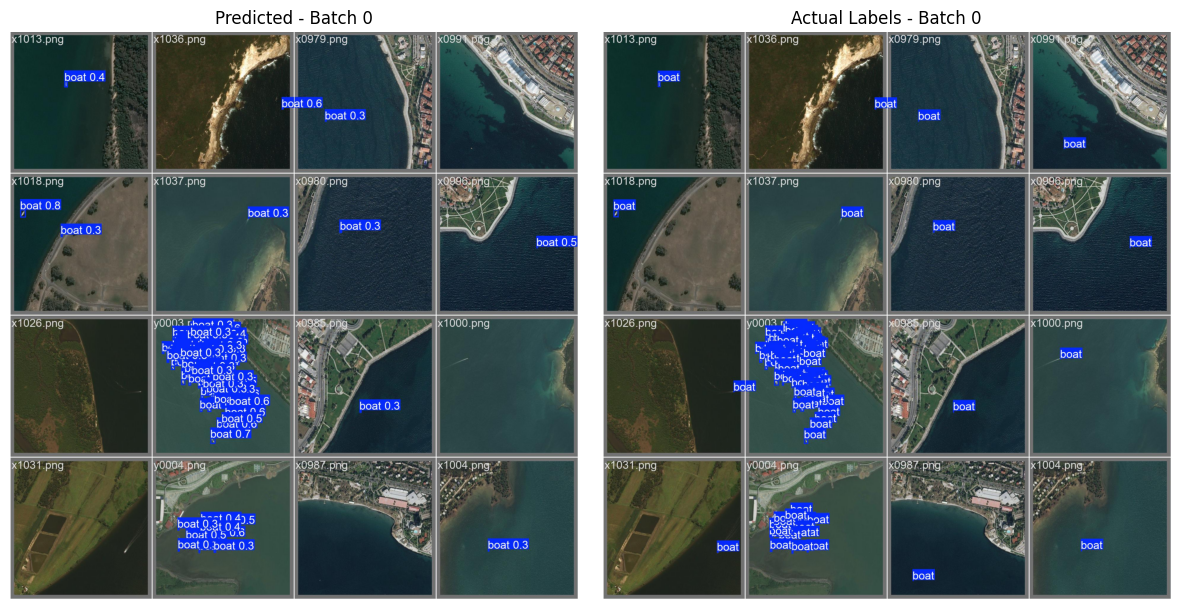

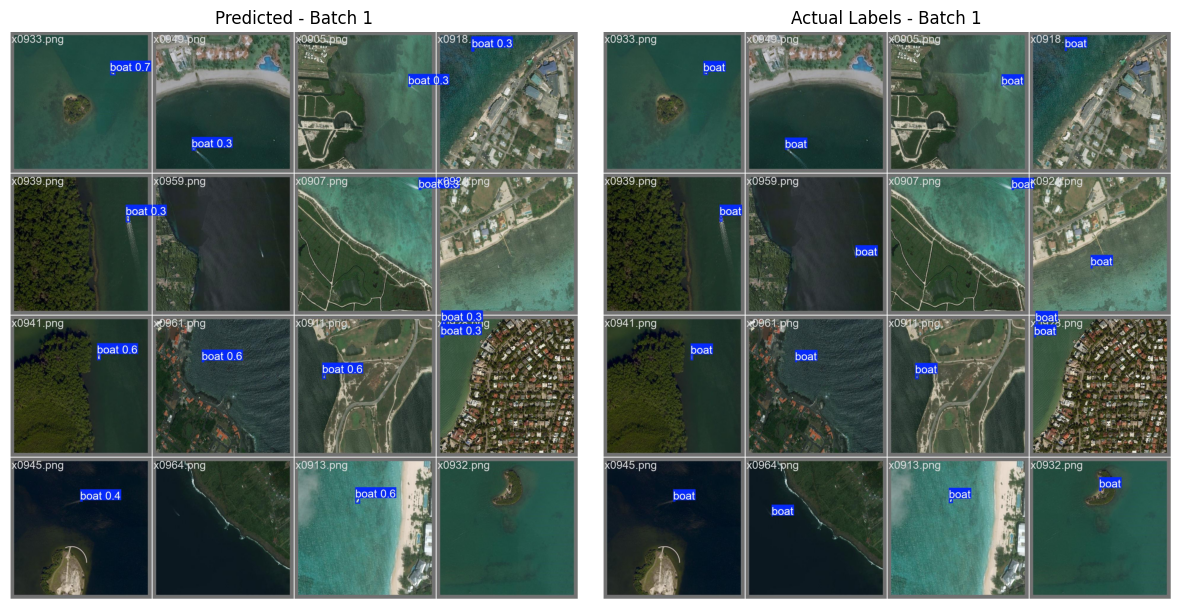

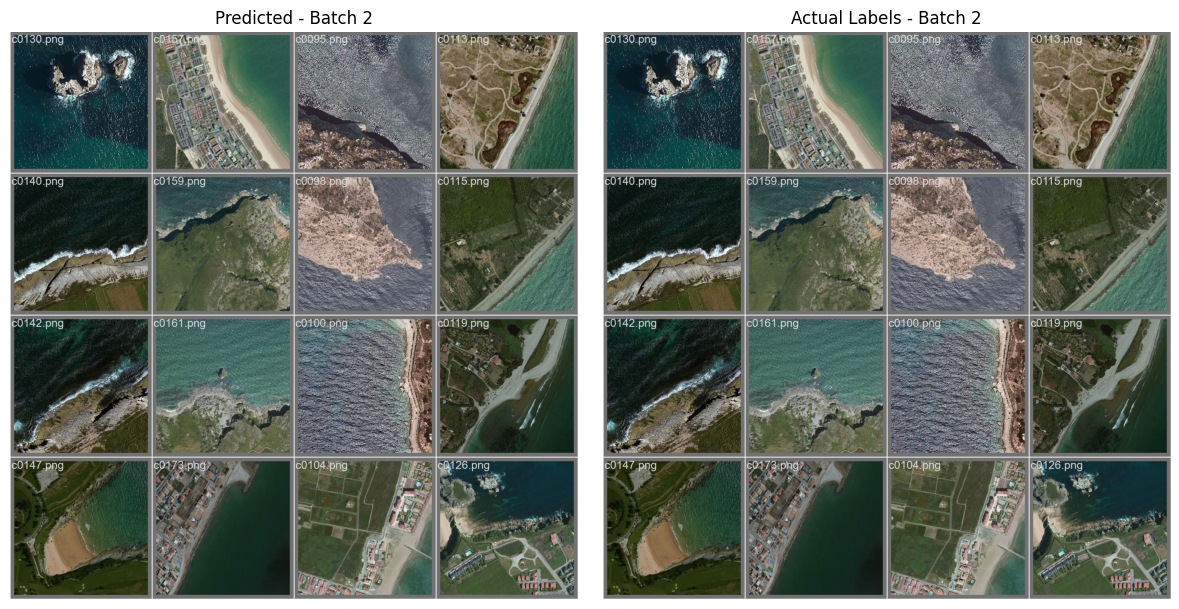

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Paths (you can change val to val2, val3, val4 if you want to see others)
val_folder = "/content/runs/detect/val"

for i in range(3):
    pred_path = f"{val_folder}/val_batch{i}_pred.jpg"
    label_path = f"{val_folder}/val_batch{i}_labels.jpg"

    # Load images
    pred_img = cv2.imread(pred_path)
    label_img = cv2.imread(label_path)

    # Convert to RGB
    pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)
    label_img = cv2.cvtColor(label_img, cv2.COLOR_BGR2RGB)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(pred_img)
    axes[0].set_title(f"Predicted - Batch {i}")
    axes[0].axis("off")

    axes[1].imshow(label_img)
    axes[1].set_title(f"Actual Labels - Batch {i}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()